# Student Performance Analyzer

Analyzes exam performance for **240 students** across **3 sections** and **5 subjects**,
including study hours and attendance. Computes grades, rankings, at-risk flags, and
correlation analysis.

An interactive version of this project is deployed as a Streamlit dashboard -- see app.py.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data/students.csv")
print(f"Loaded {len(df)} student records")
df.head()

Loaded 240 student records


,StudentID,Name,Section,Mathematics,Science,English,Computer Science,Social Studies,StudyHours,Attendance
0,STU0001,Nisha Sharma,A,85,77,86,81,78,5.1,78.5
1,STU0002,Rahul Reddy,B,75,75,81,69,76,7.3,100.0
2,STU0003,Aryan Rao,C,51,49,54,58,59,4.4,78.2
3,STU0004,Varun Mehta,A,97,93,93,96,99,8.0,85.1
4,STU0005,Kavya Thakur,B,60,75,61,68,60,5.2,74.5


## Compute Total, Average, and Grade

In [2]:
SUBJECT_COLUMNS = ["Mathematics", "Science", "English", "Computer Science", "Social Studies"]

df["Total"] = df[SUBJECT_COLUMNS].sum(axis=1)
df["Average"] = (df["Total"] / len(SUBJECT_COLUMNS)).round(2)

def grade(avg):
    if avg >= 90:
        return "A+"
    elif avg >= 75:
        return "A"
    elif avg >= 60:
        return "B"
    elif avg >= 40:
        return "C"
    else:
        return "F"

df["Grade"] = df["Average"].apply(grade)
df.head()

,StudentID,Name,Section,Mathematics,Science,English,Computer Science,Social Studies,StudyHours,Attendance,Total,Average,Grade
0,STU0001,Nisha Sharma,A,85,77,86,81,78,5.1,78.5,407,81.4,A
1,STU0002,Rahul Reddy,B,75,75,81,69,76,7.3,100.0,376,75.2,A
2,STU0003,Aryan Rao,C,51,49,54,58,59,4.4,78.2,271,54.2,C
3,STU0004,Varun Mehta,A,97,93,93,96,99,8.0,85.1,478,95.6,A+
4,STU0005,Kavya Thakur,B,60,75,61,68,60,5.2,74.5,324,64.8,B


## Rank students overall and within their section

In [3]:
df["OverallRank"] = df["Total"].rank(ascending=False, method="min").astype(int)
df["SectionRank"] = df.groupby("Section")["Total"].rank(ascending=False, method="min").astype(int)

df.sort_values("OverallRank").head(10)

,StudentID,Name,Section,Mathematics,Science,English,Computer Science,Social Studies,StudyHours,Attendance,Total,Average,Grade,OverallRank,SectionRank
3,STU0004,Varun Mehta,A,97,93,93,96,99,8.0,85.1,478,95.6,A+,1,1
211,STU0212,Aadhya Bose,B,90,93,96,100,97,6.2,96.9,476,95.2,A+,2,1
160,STU0161,Aadhya Gupta,B,89,92,96,95,95,8.0,93.5,467,93.4,A+,3,2
121,STU0122,Aryan Kumar,B,96,83,100,94,94,4.3,100.0,467,93.4,A+,3,2
196,STU0197,Tanvi Gupta,B,100,92,91,87,94,7.1,92.0,464,92.8,A+,5,4
119,STU0120,Pooja Chauhan,C,95,83,99,90,91,7.1,91.0,458,91.6,A+,6,1
117,STU0118,Krishna Yadav,A,87,88,78,89,96,7.6,68.0,438,87.6,A,7,2
231,STU0232,Reyansh Mehta,A,90,89,99,79,80,7.2,86.2,437,87.4,A,8,3
167,STU0168,Aadhya Kumar,C,72,81,91,94,93,7.0,91.6,431,86.2,A,9,2
207,STU0208,Aarav Yadav,A,81,90,84,82,94,6.2,77.5,431,86.2,A,9,4


## Flag at-risk students

Students with an average below 50 or attendance below 65% are flagged for early intervention.

In [4]:
df["AtRisk"] = (df["Average"] < 50) | (df["Attendance"] < 65)
print(f"At-risk students: {df['AtRisk'].sum()} out of {len(df)}")
df[df["AtRisk"]][["Name", "Section", "Average", "Attendance"]].head(10)

At-risk students: 67 out of 240


,Name,Section,Average,Attendance
7,Sneha Verma,B,38.8,86.2
11,Nisha Mehta,C,40.0,84.9
12,Vivaan Gupta,A,40.0,75.2
14,Priya Sharma,C,49.4,75.5
18,Vikram Gupta,A,45.4,94.5
20,Sneha Patel,C,46.2,86.8
27,Rohan Gupta,A,41.8,83.6
34,Ananya Nair,B,31.8,85.6
35,Sweta Iyer,C,31.6,90.7
37,Meera Singh,B,29.2,85.5


## Grade distribution

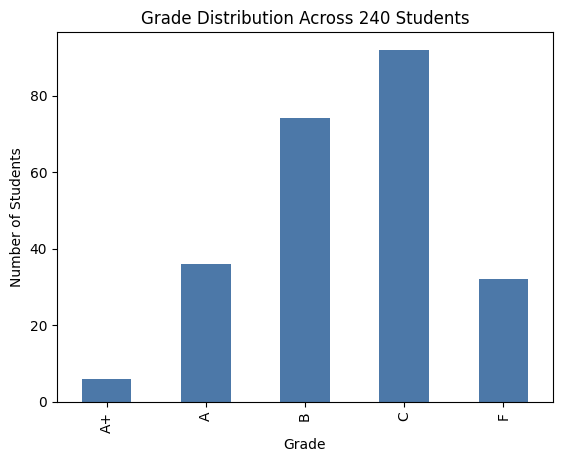

In [5]:
order = ["A+", "A", "B", "C", "F"]
dist = df["Grade"].value_counts().reindex(order)

dist.plot(kind="bar", color="#4C78A8")
plt.title("Grade Distribution Across 240 Students")
plt.ylabel("Number of Students")
plt.savefig("grade_distribution.png")
plt.show()

## Study hours vs. score correlation

Correlation between study hours and average score: 0.814


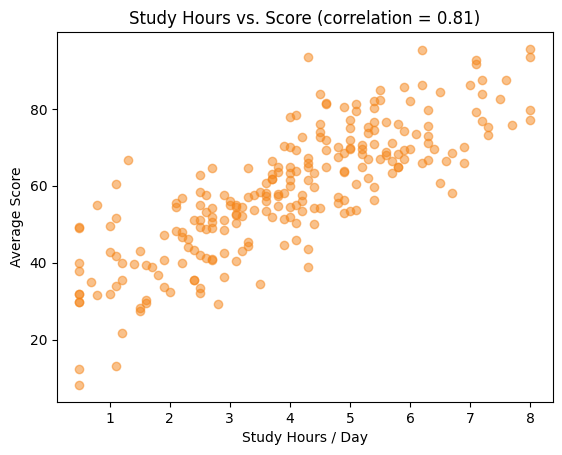

In [6]:
correlation = df["StudyHours"].corr(df["Average"])
print(f"Correlation between study hours and average score: {correlation:.3f}")

plt.scatter(df["StudyHours"], df["Average"], alpha=0.5, color="#F58518")
plt.xlabel("Study Hours / Day")
plt.ylabel("Average Score")
plt.title(f"Study Hours vs. Score (correlation = {correlation:.2f})")
plt.savefig("study_hours_correlation.png")
plt.show()

## Section-wise comparison

In [7]:
section_summary = df.groupby("Section").agg(
    Students=("Name", "count"),
    AvgScore=("Average", "mean"),
    AvgAttendance=("Attendance", "mean"),
    AtRiskCount=("AtRisk", "sum"),
).round(2)

section_summary

,Students,AvgScore,AvgAttendance,AtRiskCount
Section,,,,
A,80,56.60,82.90,26
B,80,59.21,85.02,23
C,80,60.66,85.90,18


## Export final report

In [8]:
df.sort_values("OverallRank").to_csv("final_report.csv", index=False)
print("Saved final_report.csv")

Saved final_report.csv
